# 狮头股份 600539.SH 技术指标计算：RSI、MACD、布林带、ATR

本 notebook 使用狮头股份前复权日线数据，展示四个常见技术指标的计算过程：

- RSI：观察上涨和下跌力量的相对强弱。
- MACD：观察趋势动量的变化。
- 布林带：观察价格相对均值和波动区间的位置。
- ATR：观察真实波幅和风险强度。

数据文件中的主价格字段 `open/high/low/close/pre_close/change/pct_chg` 为前复权 `qfq` 口径，原始未复权字段保留为 `raw_*`。

## 1. 参数与依赖

在 notebook 顶部集中定义股票、数据路径和指标参数，后续可以复用到其他股票。

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STOCK_NAME = "狮头股份"
TS_CODE = "600539.SH"
DATA_PATH = Path("../data/shitou_600539_qfq_daily.csv")
META_PATH = Path("../data/shitou_600539_qfq_daily.json")
OUTPUT_DIR = Path("../output")
FIGURE_DIR = OUTPUT_DIR / "figures"

RSI_PERIOD = 14
MACD_FAST = 12
MACD_SLOW = 26
MACD_SIGNAL = 9
BB_PERIOD = 20
BB_STD_MULTIPLIER = 2
ATR_PERIOD = 14

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 2. 读取数据与质量检查

先读取 CSV 和 JSON metadata，确认数据为前复权口径，并检查日期、缺失值、OHLC、成交量等基础质量。

In [2]:
df = pd.read_csv(DATA_PATH, dtype={"date": str})
with META_PATH.open("r", encoding="utf-8") as f:
    metadata = json.load(f)["metadata"]

df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
df = df.sort_values("date").reset_index(drop=True)

required_cols = [
    "date", "open", "high", "low", "close", "pre_close", "change", "pct_chg",
    "volume_hands", "volume_shares", "amount_thousand_yuan", "adj_factor",
]
missing_cols = [col for col in required_cols if col not in df.columns]
assert not missing_cols, f"缺少必要字段: {missing_cols}"
assert len(df) > 0, "数据为空"
assert df["date"].is_unique, "日期存在重复"
assert df["date"].is_monotonic_increasing, "日期未升序排列"
assert ((df["low"] <= df["open"]) & (df["open"] <= df["high"])).all(), "open 超出 high/low 范围"
assert ((df["low"] <= df["close"]) & (df["close"] <= df["high"])).all(), "close 超出 high/low 范围"
assert (df["volume_hands"] >= 0).all(), "成交量存在负数"
assert (df["adj_factor"] > 0).all(), "复权因子必须大于 0"
assert metadata.get("adjust") == "qfq", f"预期前复权 qfq，实际为 {metadata.get('adjust')}"

quality_summary = pd.DataFrame(
    {
        "item": ["stock", "ts_code", "adjust", "first_trade_date", "last_trade_date", "rows", "missing_values"],
        "value": [
            metadata.get("stock_name"),
            metadata.get("ts_code"),
            metadata.get("adjust"),
            df["date"].min().strftime("%Y-%m-%d"),
            df["date"].max().strftime("%Y-%m-%d"),
            len(df),
            int(df.isna().sum().sum()),
        ],
    }
)
quality_summary

,item,value
0,stock,狮头股份
1,ts_code,600539.SH
2,adjust,qfq
3,first_trade_date,2025-07-04
4,last_trade_date,2026-07-03
5,rows,242
6,missing_values,0


In [3]:
display(df.head())
display(df.tail())
display(df.isna().sum().to_frame("missing_count"))

,date,open,high,low,close,pre_close,change,pct_chg,volume_hands,volume_shares,amount_thousand_yuan,raw_open,raw_high,raw_low,raw_close,raw_pre_close,raw_change,raw_pct_chg,adj_factor
0,2025-07-04,10.85,11.00,10.80,10.87,10.84,0.03,0.2768,54142.02,5414202.0,59010.474,10.85,11.00,10.80,10.87,10.84,0.03,0.2768,1.214
1,2025-07-07,10.81,11.07,10.74,11.07,10.87,0.20,1.8399,45327.01,4532701.0,49265.960,10.81,11.07,10.74,11.07,10.87,0.20,1.8399,1.214
2,2025-07-08,11.05,11.47,11.00,11.23,11.07,0.16,1.4453,78358.00,7835800.0,88142.015,11.05,11.47,11.00,11.23,11.07,0.16,1.4453,1.214
3,2025-07-09,11.16,11.23,11.03,11.15,11.23,-0.08,-0.7124,44583.00,4458300.0,49633.238,11.16,11.23,11.03,11.15,11.23,-0.08,-0.7124,1.214
4,2025-07-10,11.16,11.21,11.01,11.08,11.15,-0.07,-0.6278,33197.00,3319700.0,36860.637,11.16,11.21,11.01,11.08,11.15,-0.07,-0.6278,1.214


,date,open,high,low,close,pre_close,change,pct_chg,volume_hands,volume_shares,amount_thousand_yuan,raw_open,raw_high,raw_low,raw_close,raw_pre_close,raw_change,raw_pct_chg,adj_factor
237,2026-06-29,14.32,15.46,13.30,15.10,14.32,0.78,5.4469,250208.01,25020801.0,364815.467,14.32,15.46,13.30,15.10,14.32,0.78,5.4469,1.214
238,2026-06-30,16.20,16.46,15.37,16.31,15.10,1.21,8.0132,241835.19,24183519.0,385312.857,16.20,16.46,15.37,16.31,15.10,1.21,8.0132,1.214
239,2026-07-01,16.31,17.10,16.00,17.00,16.31,0.69,4.2305,218253.00,21825300.0,366138.748,16.31,17.10,16.00,17.00,16.31,0.69,4.2305,1.214
240,2026-07-02,16.68,17.72,16.28,17.27,17.00,0.27,1.5882,236791.14,23679114.0,408637.827,16.68,17.72,16.28,17.27,17.00,0.27,1.5882,1.214
241,2026-07-03,16.92,17.50,16.77,16.83,17.27,-0.44,-2.5478,124295.00,12429500.0,211345.103,16.92,17.50,16.77,16.83,17.27,-0.44,-2.5478,1.214


,missing_count
date,0
open,0
high,0
low,0
close,0
pre_close,0
change,0
pct_chg,0
volume_hands,0
volume_shares,0


## 3. RSI：相对强弱指标

RSI 用最近一段时间的平均上涨幅度和平均下跌幅度来衡量多空力量。这里使用 14 日周期和 Wilder 平滑：

\[
RSI = 100 - \frac{100}{1 + RS}, \quad RS = \frac{AvgGain}{AvgLoss}
\]

RSI 高于 70 常被视为短期偏热，低于 30 常被视为短期偏弱。它不是单独的买卖指令，更适合观察动量和背离。

In [4]:
delta = df["close"].diff()
gain = delta.clip(lower=0)
loss = (-delta).clip(lower=0)

avg_gain = gain.ewm(alpha=1 / RSI_PERIOD, adjust=False, min_periods=RSI_PERIOD).mean()
avg_loss = loss.ewm(alpha=1 / RSI_PERIOD, adjust=False, min_periods=RSI_PERIOD).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df["rsi_14"] = 100 - 100 / (1 + rs)
df.loc[(avg_loss == 0) & (avg_gain > 0), "rsi_14"] = 100

df[["date", "close", "rsi_14"]].tail(10)

,date,close,rsi_14
232,2026-06-22,14.86,45.938104
233,2026-06-23,14.34,43.413706
234,2026-06-24,13.92,41.433254
235,2026-06-25,13.02,37.486908
236,2026-06-26,14.32,45.553685
237,2026-06-29,15.10,49.744056
238,2026-06-30,16.31,55.469591
239,2026-07-01,17.00,58.381411
240,2026-07-02,17.27,59.497475
241,2026-07-03,16.83,56.823229


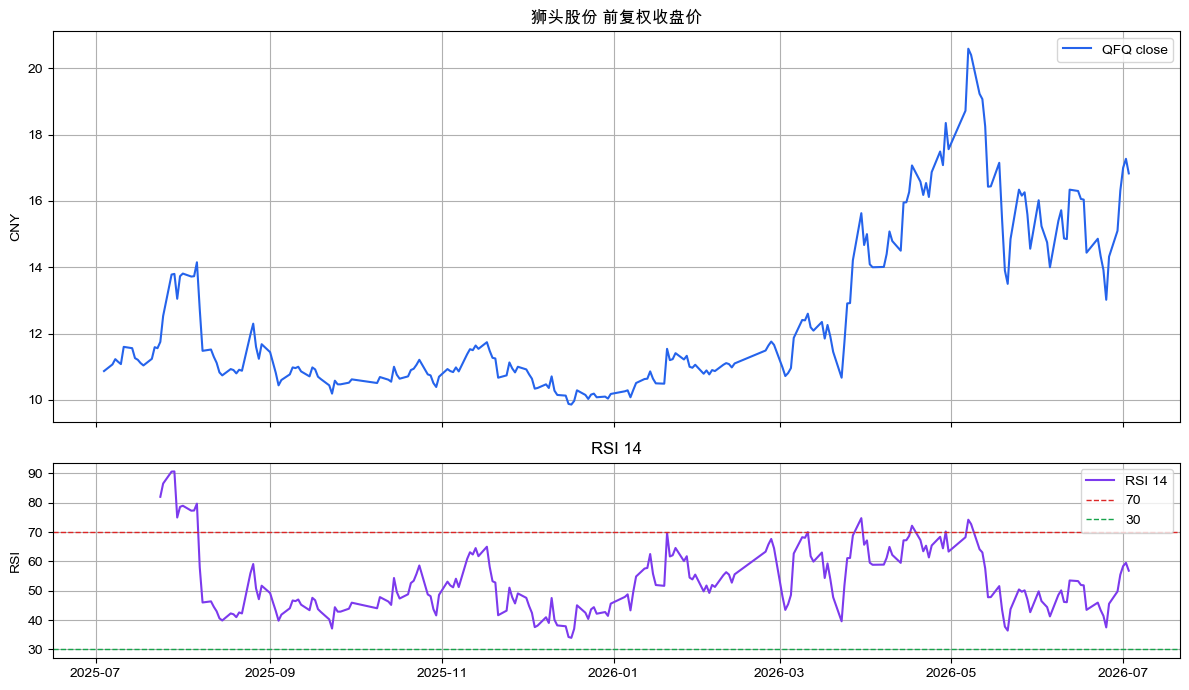

In [5]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 7), height_ratios=[2, 1])
axes[0].plot(df["date"], df["close"], label="QFQ close", color="#2563eb")
axes[0].set_title(f"{STOCK_NAME} 前复权收盘价")
axes[0].set_ylabel("CNY")
axes[0].legend()

axes[1].plot(df["date"], df["rsi_14"], label="RSI 14", color="#7c3aed")
axes[1].axhline(70, color="#dc2626", linestyle="--", linewidth=1, label="70")
axes[1].axhline(30, color="#16a34a", linestyle="--", linewidth=1, label="30")
axes[1].set_title("RSI 14")
axes[1].set_ylabel("RSI")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_rsi.png", dpi=150)
plt.show()

RSI 图中前 14 个左右的交易日会因为平滑窗口不足而出现空值，这是滚动指标的正常现象。观察时重点看 RSI 是否持续位于高位或低位，以及价格与 RSI 是否出现方向不一致。

## 4. MACD：趋势动量

MACD 比较快慢两条 EMA 的差异。默认参数为 12、26、9：

- DIF = EMA(12) - EMA(26)
- DEA = EMA(DIF, 9)
- MACD histogram = DIF - DEA

DIF 上穿 DEA 常称为金叉，说明短期动量转强；DIF 下穿 DEA 常称为死叉，说明短期动量转弱。

In [6]:
ema_fast = df["close"].ewm(span=MACD_FAST, adjust=False).mean()
ema_slow = df["close"].ewm(span=MACD_SLOW, adjust=False).mean()
df["macd_dif"] = ema_fast - ema_slow
df["macd_dea"] = df["macd_dif"].ewm(span=MACD_SIGNAL, adjust=False).mean()
df["macd_hist"] = df["macd_dif"] - df["macd_dea"]

df[["date", "close", "macd_dif", "macd_dea", "macd_hist"]].tail(10)

,date,close,macd_dif,macd_dea,macd_hist
232,2026-06-22,14.86,-0.190032,-0.185447,-0.004586
233,2026-06-23,14.34,-0.259794,-0.200316,-0.059478
234,2026-06-24,13.92,-0.344994,-0.229252,-0.115742
235,2026-06-25,13.02,-0.479610,-0.279323,-0.200286
236,2026-06-26,14.32,-0.475909,-0.318640,-0.157268
237,2026-06-29,15.10,-0.405363,-0.335985,-0.069378
238,2026-06-30,16.31,-0.248949,-0.318578,0.069629
239,2026-07-01,17.00,-0.068522,-0.268566,0.200045
240,2026-07-02,17.27,0.095157,-0.195822,0.290979
241,2026-07-03,16.83,0.187212,-0.119215,0.306427


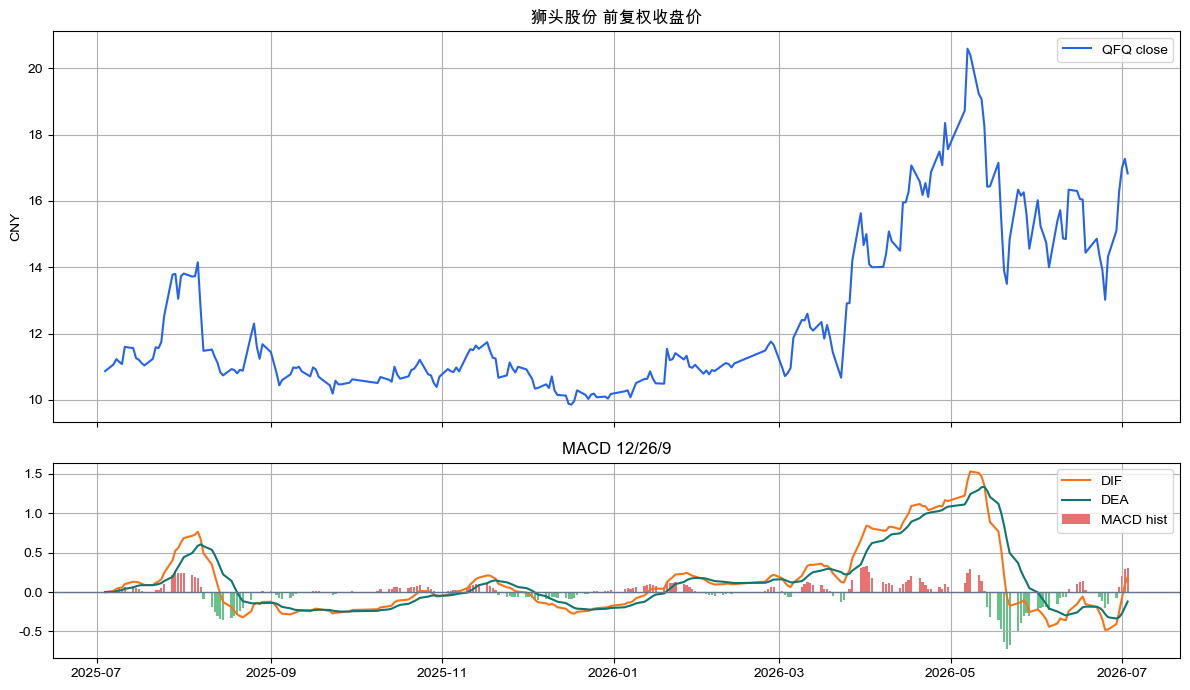

In [7]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 7), height_ratios=[2, 1])
axes[0].plot(df["date"], df["close"], label="QFQ close", color="#2563eb")
axes[0].set_title(f"{STOCK_NAME} 前复权收盘价")
axes[0].set_ylabel("CNY")
axes[0].legend()

hist_colors = np.where(df["macd_hist"] >= 0, "#dc2626", "#16a34a")
axes[1].bar(df["date"], df["macd_hist"], label="MACD hist", color=hist_colors, alpha=0.65)
axes[1].plot(df["date"], df["macd_dif"], label="DIF", color="#f97316")
axes[1].plot(df["date"], df["macd_dea"], label="DEA", color="#0f766e")
axes[1].axhline(0, color="#64748b", linewidth=1)
axes[1].set_title("MACD 12/26/9")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_macd.png", dpi=150)
plt.show()

MACD 更适合观察趋势和动量变化。柱状图持续扩大时，趋势动量更强；柱状图收缩时，说明动量在减弱。

## 5. 布林带：均值与波动区间

布林带用 20 日均线作为中轨，用 2 倍标准差构造上下轨：

\[
Upper = MA_{20} + 2 \times Std_{20}, \quad Lower = MA_{20} - 2 \times Std_{20}
\]

布林带可以帮助观察价格相对近期均值的位置，以及波动是否收缩或扩张。

In [8]:
df["bb_mid_20"] = df["close"].rolling(BB_PERIOD).mean()
bb_std = df["close"].rolling(BB_PERIOD).std()
df["bb_upper_20"] = df["bb_mid_20"] + BB_STD_MULTIPLIER * bb_std
df["bb_lower_20"] = df["bb_mid_20"] - BB_STD_MULTIPLIER * bb_std
df["bb_width_20"] = (df["bb_upper_20"] - df["bb_lower_20"]) / df["bb_mid_20"]
df["bb_percent_b_20"] = (df["close"] - df["bb_lower_20"]) / (df["bb_upper_20"] - df["bb_lower_20"])

df[["date", "close", "bb_mid_20", "bb_upper_20", "bb_lower_20", "bb_width_20", "bb_percent_b_20"]].tail(10)

,date,close,bb_mid_20,bb_upper_20,bb_lower_20,bb_width_20,bb_percent_b_20
232,2026-06-22,14.86,15.4395,16.912749,13.966251,0.190842,0.303326
233,2026-06-23,14.34,15.3395,16.826829,13.852171,0.193921,0.163995
234,2026-06-24,13.92,15.2275,16.790128,13.664872,0.205238,0.081634
235,2026-06-25,13.02,15.0655,16.835466,13.295534,0.234969,-0.077836
236,2026-06-26,14.32,15.0020,16.783822,13.220178,0.237545,0.308623
237,2026-06-29,15.10,15.0290,16.798947,13.259053,0.235538,0.520057
238,2026-06-30,16.31,15.0435,16.851963,13.235037,0.240431,0.850159
239,2026-07-01,17.00,15.1315,17.140399,13.122601,0.265525,0.965056
240,2026-07-02,17.27,15.2455,17.468002,13.022998,0.291562,0.955455
241,2026-07-03,16.83,15.3495,17.667008,13.031992,0.301965,0.819416


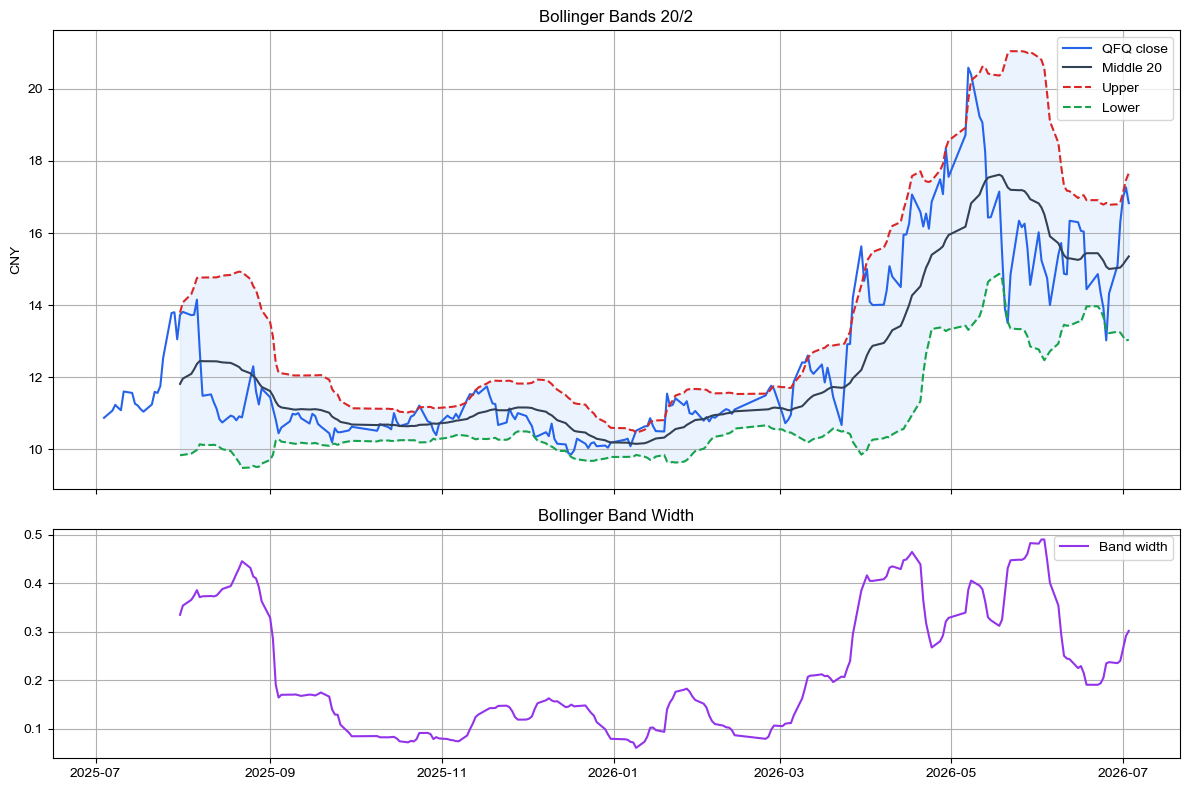

In [9]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 8), height_ratios=[2, 1])
axes[0].plot(df["date"], df["close"], label="QFQ close", color="#2563eb")
axes[0].plot(df["date"], df["bb_mid_20"], label="Middle 20", color="#334155")
axes[0].plot(df["date"], df["bb_upper_20"], label="Upper", color="#dc2626", linestyle="--")
axes[0].plot(df["date"], df["bb_lower_20"], label="Lower", color="#16a34a", linestyle="--")
axes[0].fill_between(
    df["date"],
    df["bb_lower_20"].to_numpy(dtype=float),
    df["bb_upper_20"].to_numpy(dtype=float),
    color="#93c5fd",
    alpha=0.18,
)
axes[0].set_title("Bollinger Bands 20/2")
axes[0].set_ylabel("CNY")
axes[0].legend()

axes[1].plot(df["date"], df["bb_width_20"], label="Band width", color="#9333ea")
axes[1].set_title("Bollinger Band Width")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_bollinger_bands.png", dpi=150)
plt.show()

价格接近上轨说明处于近期相对高位，接近下轨说明处于近期相对低位。布林带宽度变小表示波动收敛，宽度变大表示波动增强。

## 6. ATR：平均真实波幅

ATR 不判断方向，只衡量波动强度。真实波幅 True Range 取以下三者最大值：

- 当日最高价 - 当日最低价
- 当日最高价 - 前一日收盘价的绝对值
- 当日最低价 - 前一日收盘价的绝对值

这里使用 14 日 Wilder 平滑，并额外计算 `atr_pct_14`，方便理解波动幅度占股价的比例。

In [10]:
tr_1 = df["high"] - df["low"]
tr_2 = (df["high"] - df["close"].shift(1)).abs()
tr_3 = (df["low"] - df["close"].shift(1)).abs()
df["true_range"] = pd.concat([tr_1, tr_2, tr_3], axis=1).max(axis=1)
df["atr_14"] = df["true_range"].ewm(alpha=1 / ATR_PERIOD, adjust=False, min_periods=ATR_PERIOD).mean()
df["atr_pct_14"] = df["atr_14"] / df["close"] * 100

df[["date", "close", "true_range", "atr_14", "atr_pct_14"]].tail(10)

,date,close,true_range,atr_14,atr_pct_14
232,2026-06-22,14.86,1.26,1.260092,8.479761
233,2026-06-23,14.34,0.88,1.232943,8.597929
234,2026-06-24,13.92,0.75,1.198447,8.609533
235,2026-06-25,13.02,1.23,1.200701,9.221972
236,2026-06-26,14.32,1.32,1.209222,8.444289
237,2026-06-29,15.10,2.16,1.277135,8.457847
238,2026-06-30,16.31,1.36,1.283054,7.866670
239,2026-07-01,17.00,1.10,1.269979,7.470462
240,2026-07-02,17.27,1.44,1.282123,7.423989
241,2026-07-03,16.83,0.73,1.242686,7.383753


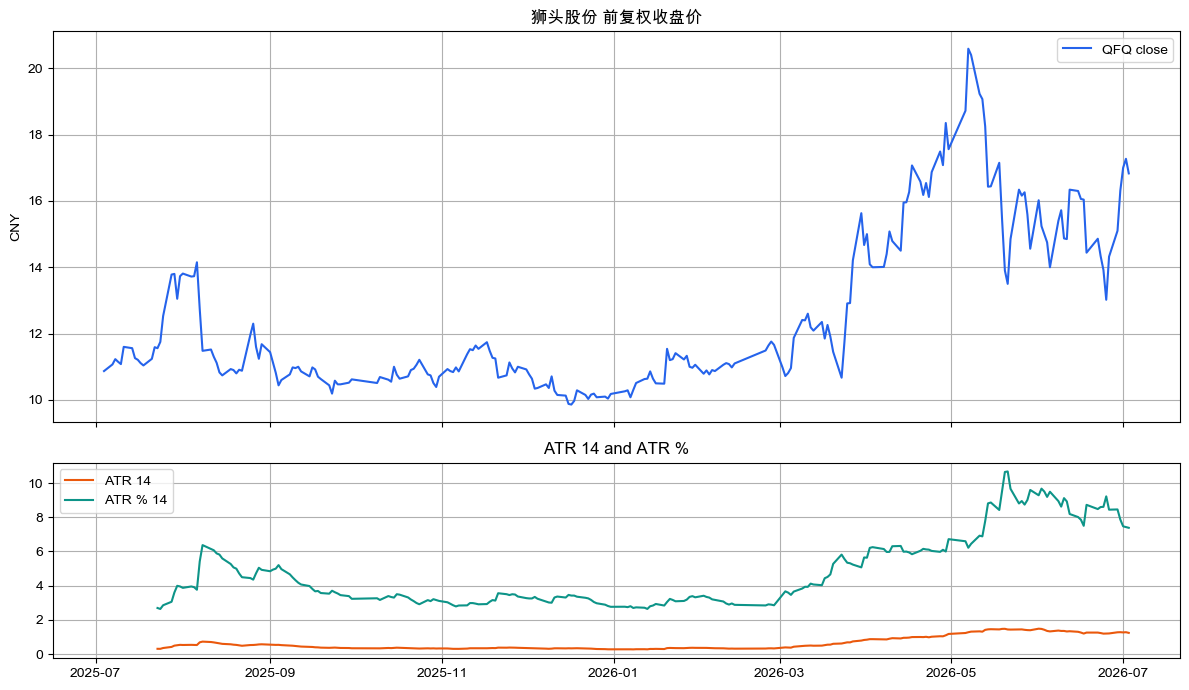

In [11]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 7), height_ratios=[2, 1])
axes[0].plot(df["date"], df["close"], label="QFQ close", color="#2563eb")
axes[0].set_title(f"{STOCK_NAME} 前复权收盘价")
axes[0].set_ylabel("CNY")
axes[0].legend()

axes[1].plot(df["date"], df["atr_14"], label="ATR 14", color="#ea580c")
axes[1].plot(df["date"], df["atr_pct_14"], label="ATR % 14", color="#0d9488")
axes[1].set_title("ATR 14 and ATR %")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_atr.png", dpi=150)
plt.show()

ATR 上升表示波动扩大，不代表价格方向一定向上；ATR 下降表示波动收敛。`atr_pct_14` 可以帮助把波动转成相对股价的百分比来观察。

## 7. 汇总表与结果导出

将原始行情和四组指标合并到同一张表，导出 CSV 和 JSON，供后续课程内容或可视化页面复用。

In [12]:
indicator_fields = [
    "date", "open", "high", "low", "close", "volume_hands",
    "rsi_14",
    "macd_dif", "macd_dea", "macd_hist",
    "bb_mid_20", "bb_upper_20", "bb_lower_20", "bb_width_20", "bb_percent_b_20",
    "true_range", "atr_14", "atr_pct_14",
]

result = df[indicator_fields].copy()
result["date"] = result["date"].dt.strftime("%Y%m%d")

csv_output = OUTPUT_DIR / "shitou_600539_indicators.csv"
json_output = OUTPUT_DIR / "shitou_600539_indicators.json"
result.to_csv(csv_output, index=False, encoding="utf-8")

json_safe_result = result.astype(object).where(pd.notna(result), None)
output_payload = {
    "metadata": {
        "stock_name": STOCK_NAME,
        "ts_code": TS_CODE,
        "source_data": str(DATA_PATH),
        "adjust": metadata.get("adjust"),
        "record_count": int(len(result)),
        "first_trade_date": result["date"].iloc[0],
        "last_trade_date": result["date"].iloc[-1],
        "indicators": {
            "rsi": {"period": RSI_PERIOD, "smoothing": "Wilder"},
            "macd": {"fast": MACD_FAST, "slow": MACD_SLOW, "signal": MACD_SIGNAL},
            "bollinger_bands": {"period": BB_PERIOD, "std_multiplier": BB_STD_MULTIPLIER},
            "atr": {"period": ATR_PERIOD, "smoothing": "Wilder"},
        },
    },
    "data": json_safe_result.to_dict(orient="records"),
}
json_output.write_text(json.dumps(output_payload, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")

print(f"CSV 输出: {csv_output}")
print(f"JSON 输出: {json_output}")
result.tail(10)

CSV 输出: ../output/shitou_600539_indicators.csv
JSON 输出: ../output/shitou_600539_indicators.json


,date,open,high,low,close,volume_hands,rsi_14,macd_dif,macd_dea,macd_hist,bb_mid_20,bb_upper_20,bb_lower_20,bb_width_20,bb_percent_b_20,true_range,atr_14,atr_pct_14
232,20260622,14.01,14.88,13.62,14.86,199308.83,45.938104,-0.190032,-0.185447,-0.004586,15.4395,16.912749,13.966251,0.190842,0.303326,1.26,1.260092,8.479761
233,20260623,14.65,14.67,13.98,14.34,122370.12,43.413706,-0.259794,-0.200316,-0.059478,15.3395,16.826829,13.852171,0.193921,0.163995,0.88,1.232943,8.597929
234,20260624,14.29,14.36,13.61,13.92,94372.52,41.433254,-0.344994,-0.229252,-0.115742,15.2275,16.790128,13.664872,0.205238,0.081634,0.75,1.198447,8.609533
235,20260625,13.69,13.94,12.71,13.02,165640.01,37.486908,-0.479610,-0.279323,-0.200286,15.0655,16.835466,13.295534,0.234969,-0.077836,1.23,1.200701,9.221972
236,20260626,13.01,14.32,13.00,14.32,180928.38,45.553685,-0.475909,-0.318640,-0.157268,15.0020,16.783822,13.220178,0.237545,0.308623,1.32,1.209222,8.444289
237,20260629,14.32,15.46,13.30,15.10,250208.01,49.744056,-0.405363,-0.335985,-0.069378,15.0290,16.798947,13.259053,0.235538,0.520057,2.16,1.277135,8.457847
238,20260630,16.20,16.46,15.37,16.31,241835.19,55.469591,-0.248949,-0.318578,0.069629,15.0435,16.851963,13.235037,0.240431,0.850159,1.36,1.283054,7.866670
239,20260701,16.31,17.10,16.00,17.00,218253.00,58.381411,-0.068522,-0.268566,0.200045,15.1315,17.140399,13.122601,0.265525,0.965056,1.10,1.269979,7.470462
240,20260702,16.68,17.72,16.28,17.27,236791.14,59.497475,0.095157,-0.195822,0.290979,15.2455,17.468002,13.022998,0.291562,0.955455,1.44,1.282123,7.423989
241,20260703,16.92,17.50,16.77,16.83,124295.00,56.823229,0.187212,-0.119215,0.306427,15.3495,17.667008,13.031992,0.301965,0.819416,0.73,1.242686,7.383753


## 8. 小结

| 指标 | 回答的问题 |
| --- | --- |
| RSI | 最近上涨和下跌力量谁更强，是否短期偏热或偏弱 |
| MACD | 趋势动量是否增强、减弱或发生方向切换 |
| 布林带 | 价格相对近期均值和波动区间的位置 |
| ATR | 当前波动和风险幅度有多大 |

四个指标关注的问题不同，适合结合使用：RSI 看短期强弱，MACD 看趋势动量，布林带看价格区间，ATR 看波动风险。